# TDA Pipeline Validation Gates — v3

**v2 result:** A passed (but sine control was degenerate — integer period
100 gives only ~100 unique embedding points, hence CV=0.000 and
top1/top2=1.4e8). B failed entirely (torus top1 at its own floor).
C failed (Lorenz 1.34-1.69x own floor, worse than v1's 2.5x vs shared floor).

**v3 rationale (fixed a priori):**
- Takens' theorem guarantees an embedding only for d >= 2*dim+1.
  Lorenz (dim ~2.06) and the 2-torus both require d >= 5. The d=3
  failures on B and C are consistent with operating below the guarantee.
  -> d=5 becomes the primary configuration BY THEORY, not by tuning.
- Sine period -> 96.7 (non-integer) to remove duplicate-point degeneracy.
- Gate F (seed stability) moves to lorenz_x (generic, non-repeating).
- n_points 800 -> 1500 (hole-scale resolution).
- NEW state-space discriminator arm: VR on the TRUE Lorenz (x,y,z) cloud.
  Distinguishes E1 (delay embedding is the lossy step) from E3 (the
  max-H1 statistic is weak even on the true attractor).
- Floors reported against BOTH nulls: own-shuffle (may be inflated for
  multimodal marginals — E2) and the white-noise reference.
- d=3 arm retained as diagnostic to quantify the embedding-dimension
  effect and complete the v1->v2 attribution.
- THRESHOLDS UNCHANGED. Gate B's top1 criterion is promoted to HARD at
  d=5 (justified by theory: with a valid embedding dimension, the
  dominant torus loop must be detectable, else the instrument is blind
  to multi-frequency structure — which is what Weather has).

**Pre-registered expectations:**
A: pass at both d, finite top1/top2, nonzero seed-CV on Gate F.
B(d=5): top1 clears floor if the Takens bound was the binding constraint.
C(d=5): clears if E1 dominates; stays ~1.5x if E3.
State-space arm: >=3x under E1 or E2; fails only under E3.
D/E: pass.

**Kill criterion:** C fails at d=5/1500 AND the state-space arm fails
-> max-H1-persistence is not a validated instrument at these data
lengths; the geometry branch needs a different instrument.

Runtime: ~20-60 min CPU (~110 ripser calls at 1500 points).

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

from ripser import ripser

D_PRIMARY   = 5
D_DIAG      = 3
N_POINTS    = 1500
MAX_TAU     = 80
M_SUR       = 10
Q_FLOOR     = 95
EPS         = 1e-12

## Pipeline primitives (unchanged from v2; delay/subsample/ripser/stats
verbatim from the real-data notebook)

In [2]:
def mi_curve(x, max_lag=100, n_bins=16):
    mis = []
    for lag in range(1, max_lag + 1):
        x1, x2 = x[:-lag], x[lag:]
        hist2d, _, _ = np.histogram2d(x1, x2, bins=n_bins)
        hist2d = hist2d / hist2d.sum()
        px = hist2d.sum(axis=1, keepdims=True)
        py = hist2d.sum(axis=0, keepdims=True)
        outer = px @ py
        mask = (hist2d > 0) & (outer > 0)
        mis.append(np.sum(hist2d[mask] * np.log(hist2d[mask] / outer[mask])))
    return np.array(mis)

def robust_tau(x, max_lag=100, n_bins=16, smooth_w=5, min_win=2):
    """v2 tau selection: smoothed MI, windowed minimum, ACF fallback."""
    mis = mi_curve(x, max_lag=max_lag, n_bins=n_bins)
    kernel = np.ones(smooth_w) / smooth_w
    pad = smooth_w // 2
    padded = np.concatenate([np.full(pad, mis[0]), mis, np.full(pad, mis[-1])])
    smooth = np.convolve(padded, kernel, mode='valid')
    for i in range(min_win, len(smooth) - min_win):
        window = smooth[i - min_win: i + min_win + 1]
        if smooth[i] == window.min() and (window > smooth[i]).sum() == len(window) - 1:
            return i + 1, mis, smooth
    xc = x - x.mean()
    acf_denom = np.dot(xc, xc)
    for lag in range(1, max_lag + 1):
        if np.dot(xc[:-lag], xc[lag:]) / acf_denom <= 0:
            return lag, mis, smooth
    return max_lag // 4, mis, smooth

def delay_embed(x, d, tau):
    N = len(x) - (d - 1) * tau
    if N <= 0:
        raise ValueError(f"Signal too short for d={d}, tau={tau}: len={len(x)}")
    return np.stack([x[i*tau : i*tau + N] for i in range(d)], axis=1)

def subsample_cloud(cloud, n=800, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(cloud), size=min(n, len(cloud)), replace=False)
    return cloud[idx]

def compute_h1_persistence(cloud):
    result = ripser(cloud, maxdim=1)
    h1 = result['dgms'][1]
    return h1[np.isfinite(h1[:, 1])] if len(h1) > 0 else h1

def persistence_stats(h1_pairs):
    if len(h1_pairs) == 0:
        return {'max_pers': 0.0, 'total_pers': 0.0, 'n_features': 0}
    pers = h1_pairs[:, 1] - h1_pairs[:, 0]
    return {'max_pers': float(pers.max()), 'total_pers': float(pers.sum()), 'n_features': len(pers)}

def simulate_lorenz(n=5000, dt=0.01, sigma=10, rho=28, beta=8/3):
    x, y, z = 0.1, 0.0, 0.0
    xs, ys, zs = [x], [y], [z]
    for _ in range(n - 1):
        k1x = sigma * (y - x); k1y = x * (rho - z) - y; k1z = x * y - beta * z
        k2x = sigma * ((y + dt/2*k1y) - (x + dt/2*k1x))
        k2y = (x + dt/2*k1x) * (rho - (z + dt/2*k1z)) - (y + dt/2*k1y)
        k2z = (x + dt/2*k1x) * (y + dt/2*k1y) - beta * (z + dt/2*k1z)
        k3x = sigma * ((y + dt/2*k2y) - (x + dt/2*k2x))
        k3y = (x + dt/2*k2x) * (rho - (z + dt/2*k2z)) - (y + dt/2*k2y)
        k3z = (x + dt/2*k2x) * (y + dt/2*k2y) - beta * (z + dt/2*k2z)
        k4x = sigma * ((y + dt*k3y) - (x + dt*k3x))
        k4y = (x + dt*k3x) * (rho - (z + dt*k3z)) - (y + dt*k3y)
        k4z = (x + dt*k3x) * (y + dt*k3y) - beta * (z + dt*k3z)
        x += dt/6*(k1x+2*k2x+2*k3x+k4x)
        y += dt/6*(k1y+2*k2y+2*k3y+k4y)
        z += dt/6*(k1z+2*k2z+2*k3z+k4z)
        xs.append(x); ys.append(y); zs.append(z)
    return np.array([xs, ys, zs]).T

## Control signals

Sine/torus base period changed to 96.7 samples (non-integer) so integer
sampling never revisits the exact same phase — removes the duplicate-point
degeneracy discovered in v2 (only ~100 unique embedding points).

In [3]:
N_CONTROL = 3000
t = np.arange(N_CONTROL)
rng_master = np.random.default_rng(42)
P0 = 96.7
GOLDEN = (1 + np.sqrt(5)) / 2

sig_sine  = np.sin(2 * np.pi * t / P0)
sig_torus = np.sin(2 * np.pi * t / P0) + 0.8 * np.sin(2 * np.pi * t * GOLDEN / P0)
sig_noise = rng_master.standard_normal(N_CONTROL)

phi = 0.95
eps = rng_master.standard_normal(N_CONTROL)
sig_ar1 = np.empty(N_CONTROL)
sig_ar1[0] = eps[0]
for i in range(1, N_CONTROL):
    sig_ar1[i] = phi * sig_ar1[i-1] + eps[i]

lorenz_ctrl = simulate_lorenz(n=5000)[500:3500]

signals = {
    'sine': sig_sine, 'torus': sig_torus,
    'white_noise': sig_noise, 'ar1': sig_ar1,
    'lorenz_x': lorenz_ctrl[:, 0], 'lorenz_y': lorenz_ctrl[:, 1], 'lorenz_z': lorenz_ctrl[:, 2],
}

## Analysis wrappers

In [4]:
def gate_analyse(x, d, max_tau=MAX_TAU, n_points=N_POINTS, seed=42, label="", keep_mi=False):
    x = (x - x.mean()) / (x.std() + 1e-8)
    tau, mis, smooth = robust_tau(x, max_lag=max_tau)
    cloud = delay_embed(x, d=d, tau=tau)
    cloud_s = subsample_cloud(cloud, n=n_points, seed=seed)
    h1 = compute_h1_persistence(cloud_s)
    stats = persistence_stats(h1)
    lifetimes = np.sort(h1[:, 1] - h1[:, 0])[::-1] if len(h1) > 0 else np.array([])
    top = lambda k: float(lifetimes[k]) if len(lifetimes) > k else 0.0
    out = {'label': label, 'd': d, 'tau': tau, 'n_features': stats['n_features'],
           'max_pers': stats['max_pers'], 'total_pers': stats['total_pers'],
           'top1': top(0), 'top2': top(1), 'top3': top(2),
           'lifetimes': lifetimes, 'cloud': cloud_s}
    if keep_mi:
        out['mi_raw'], out['mi_smooth'] = mis, smooth
    return out

def shuffle_floor(x, d, M=M_SUR, q=Q_FLOOR, seed0=1000):
    tops = []
    for m in range(M):
        rng = np.random.default_rng(seed0 + m)
        tops.append(gate_analyse(rng.permutation(x), d=d, label=f'shuf{m}')['top1'])
    return float(np.percentile(tops, q)), tops

def n_unique_rows(cloud, dec=10):
    return np.unique(np.round(cloud, dec), axis=0).shape[0]

## Degeneracy check (v2 lesson: every control verified generic)

In [5]:
for k, x in signals.items():
    r = gate_analyse(x, d=D_PRIMARY, label=k)
    print(f"{k:>12}: unique rows in subsampled cloud = {n_unique_rows(r['cloud'])} / {len(r['cloud'])}")

        sine: unique rows in subsampled cloud = 858 / 1500
       torus: unique rows in subsampled cloud = 1500 / 1500
 white_noise: unique rows in subsampled cloud = 1500 / 1500
         ar1: unique rows in subsampled cloud = 1500 / 1500
    lorenz_x: unique rows in subsampled cloud = 1500 / 1500
    lorenz_y: unique rows in subsampled cloud = 1500 / 1500
    lorenz_z: unique rows in subsampled cloud = 1500 / 1500


## Main runs: d=5 (primary) and d=3 (diagnostic), own floors at d=5,
white-noise reference floor at both d

In [6]:
results = {}     # (key, d) -> result
floors_own = {}  # key -> own shuffle floor at d=5

for d in [D_DIAG, D_PRIMARY]:
    for k, x in signals.items():
        results[(k, d)] = gate_analyse(x, d=d, label=k, keep_mi=(d == D_PRIMARY))

print("computing per-signal shuffle floors at d=5 (this is the slow part)...")
for k, x in signals.items():
    floors_own[k], _ = shuffle_floor(x, d=D_PRIMARY)
    print(f"  {k:>12}: own floor (p{Q_FLOOR}) = {floors_own[k]:.4f}")

wn_floor_d3, _ = shuffle_floor(sig_noise, d=D_DIAG)
wn_floor_d5 = floors_own['white_noise']

computing per-signal shuffle floors at d=5 (this is the slow part)...
          sine: own floor (p95) = 0.5456
         torus: own floor (p95) = 0.5242
   white_noise: own floor (p95) = 0.5283
           ar1: own floor (p95) = 0.5807
      lorenz_x: own floor (p95) = 0.6406
      lorenz_y: own floor (p95) = 0.6861
      lorenz_z: own floor (p95) = 0.5916


In [7]:
rows = []
for k in signals:
    r3, r5 = results[(k, D_DIAG)], results[(k, D_PRIMARY)]
    rows.append({
        'signal': k,
        'tau_d5': r5['tau'],
        'top1_d3': round(r3['top1'], 4),
        'top1_d5': round(r5['top1'], 4),
        'own_floor_d5': round(floors_own[k], 4),
        'top1/own_d5': round(r5['top1'] / max(floors_own[k], EPS), 2),
        'top1/wn_d5': round(r5['top1'] / max(wn_floor_d5, EPS), 2),
        'top1/top2_d5': round(r5['top1'] / max(r5['top2'], EPS), 2),
        'top1/total_d5': round(r5['top1'] / max(r5['total_pers'], EPS), 3),
        'n_H1_d5': r5['n_features'],
    })
df_main = pd.DataFrame(rows)
print(df_main.to_string(index=False))
df_main.to_csv('tda_gate_controls_v3.csv', index=False)

     signal  tau_d5  top1_d3  top1_d5  own_floor_d5  top1/own_d5  top1/wn_d5  top1/top2_d5  top1/total_d5  n_H1_d5
       sine      22   2.7652   3.7614        0.5456         6.89        7.12  3.761413e+12          1.000        1
      torus      19   0.4983   1.9731        0.5242         3.76        3.73  1.380000e+00          0.044      628
white_noise       7   0.3282   0.4462        0.5283         0.84        0.84  1.060000e+00          0.003     1407
        ar1      46   0.4452   0.6052        0.5807         1.04        1.15  1.070000e+00          0.006     1068
   lorenz_x      16   1.0085   1.9658        0.6406         3.07        3.72  1.260000e+00          0.089      449
   lorenz_y      16   0.8082   1.8227        0.6861         2.66        3.45  1.490000e+00          0.074      456
   lorenz_z      16   0.6344   0.8887        0.5916         1.50        1.68  1.440000e+00          0.030      489


## State-space discriminator arm (E1 vs E3)

VR on the TRUE Lorenz (x,y,z) cloud — no delay embedding. Null: permute
each coordinate independently (destroys the manifold, keeps marginals).
Diagnostic only: real datasets have no accessible state space, so this
cannot rescue the pipeline — it localises where information is lost.

In [8]:
def statespace_analyse(traj, n_points=N_POINTS, seed=42):
    Xs = (traj - traj.mean(0)) / (traj.std(0) + 1e-8)
    cloud = subsample_cloud(Xs, n=n_points, seed=seed)
    h1 = compute_h1_persistence(cloud)
    stats = persistence_stats(h1)
    lifetimes = np.sort(h1[:, 1] - h1[:, 0])[::-1] if len(h1) > 0 else np.array([])
    top = lambda kk: float(lifetimes[kk]) if len(lifetimes) > kk else 0.0
    return {'top1': top(0), 'top2': top(1), 'n_features': stats['n_features'],
            'max_pers': stats['max_pers'], 'total_pers': stats['total_pers'],
            'cloud': cloud, 'lifetimes': lifetimes}

ss = statespace_analyse(lorenz_ctrl)
ss_tops = []
for m in range(M_SUR):
    rng = np.random.default_rng(2000 + m)
    shuf = np.column_stack([rng.permutation(lorenz_ctrl[:, c]) for c in range(3)])
    ss_tops.append(statespace_analyse(shuf, seed=42)['top1'])
ss_floor = float(np.percentile(ss_tops, Q_FLOOR))

print(f"state-space Lorenz: top1={ss['top1']:.4f}, top2={ss['top2']:.4f}, "
      f"own floor={ss_floor:.4f}, top1/floor={ss['top1']/max(ss_floor,EPS):.2f}, "
      f"top1/wn_d3_floor={ss['top1']/max(wn_floor_d3,EPS):.2f}")

state-space Lorenz: top1=0.9967, top2=0.5571, own floor=0.5945, top1/floor=1.68, top1/wn_d3_floor=2.58


## Gate F — seed stability on lorenz_x (d=5)

In [9]:
SEEDS = [42, 123, 777]
seed_mp = [gate_analyse(lorenz_ctrl[:, 0], d=D_PRIMARY, seed=s)['max_pers'] for s in SEEDS]
seed_cv = float(np.std(seed_mp) / (np.mean(seed_mp) + 1e-12))
print(f"lorenz_x max_pers across seeds {SEEDS}: {[f'{v:.4f}' for v in seed_mp]} -> CV={seed_cv:.3f}")

lorenz_x max_pers across seeds [42, 123, 777]: ['1.9658', '2.2237', '2.0573'] -> CV=0.051


## Verdicts — thresholds unchanged; evaluated at d=5

In [10]:
def R(k):  # result at primary d
    return results[(k, D_PRIMARY)]

def rel_own(k):
    return R(k)['top1'] / max(floors_own[k], EPS)

def ratio12(k):
    return R(k)['top1'] / max(R(k)['top2'], EPS)

gates = []

gates.append({'gate': 'A_sine', 'type': 'hard',
    'criterion': 'top1/top2 >= 3 AND top1 >= 3*own_floor',
    'observed': f"top1/top2={ratio12('sine'):.2f}, top1/floor={rel_own('sine'):.2f}, tau={R('sine')['tau']}",
    'pass': bool(ratio12('sine') >= 3 and rel_own('sine') >= 3)})

gates.append({'gate': 'B_torus_top1', 'type': 'hard',
    'criterion': 'top1 >= 3*own_floor (dominant loop of multi-frequency signal)',
    'observed': f"top1/floor={rel_own('torus'):.2f}, tau={R('torus')['tau']}",
    'pass': bool(rel_own('torus') >= 3)})

gates.append({'gate': 'B_torus_top2', 'type': 'soft',
    'criterion': 'top2 >= 2*own_floor (second loop resolved)',
    'observed': f"top2/floor={R('torus')['top2']/max(floors_own['torus'],EPS):.2f}",
    'pass': bool(R('torus')['top2'] >= 2 * floors_own['torus'])})

lz_rel = [rel_own(k) for k in ['lorenz_x', 'lorenz_y', 'lorenz_z']]
gates.append({'gate': 'C_lorenz', 'type': 'hard',
    'criterion': 'median(top1/own_floor over x,y,z) >= 2 AND best >= 3',
    'observed': f"per-ch top1/floor={[f'{v:.2f}' for v in lz_rel]}",
    'pass': bool(np.median(lz_rel) >= 2 and max(lz_rel) >= 3)})

gates.append({'gate': 'D_white_noise', 'type': 'hard',
    'criterion': 'n_features >= 3 AND top1/top2 < 2 AND top1/own_floor < 2',
    'observed': f"n={R('white_noise')['n_features']}, top1/top2={ratio12('white_noise'):.2f}, "
                f"top1/floor={rel_own('white_noise'):.2f}",
    'pass': bool(R('white_noise')['n_features'] >= 3 and ratio12('white_noise') < 2
                 and rel_own('white_noise') < 2)})

gates.append({'gate': 'E_ar1', 'type': 'hard',
    'criterion': '(top1/top2 < 2) OR (top1 < 2*own_floor)',
    'observed': f"top1/top2={ratio12('ar1'):.2f}, top1/floor={rel_own('ar1'):.2f}",
    'pass': bool(ratio12('ar1') < 2 or rel_own('ar1') < 2)})

gates.append({'gate': 'F_seed_stability', 'type': 'hard',
    'criterion': 'CV(max_pers, lorenz_x, 3 seeds) < 0.20 AND CV > 0 (non-degenerate)',
    'observed': f"CV={seed_cv:.4f}",
    'pass': bool(0 < seed_cv < 0.20)})

ss_rel = ss['top1'] / max(ss_floor, EPS)
gates.append({'gate': 'G_statespace (diagnostic)', 'type': 'diagnostic',
    'criterion': 'true-state Lorenz top1 >= 3*own_floor',
    'observed': f"top1/floor={ss_rel:.2f}",
    'pass': bool(ss_rel >= 3)})

df_gates = pd.DataFrame(gates)
print(df_gates[['gate', 'type', 'criterion', 'observed', 'pass']].to_string(index=False))
df_gates.to_csv('tda_gate_verdicts_v3.csv', index=False)

hard_fail = [g['gate'] for g in gates if g['type'] == 'hard' and not g['pass']]
c_pass = next(g['pass'] for g in gates if g['gate'] == 'C_lorenz')
g_pass = next(g['pass'] for g in gates if g['gate'].startswith('G_'))

print()
if not hard_fail:
    print("VERDICT: ALL HARD GATES PASSED at d=5.")
    print("-> Mirror to real-data notebook: robust_tau, d=5, n_points=1500,")
    print("   per-channel shuffle floors, report top1/own_floor + top1/top2 +")
    print("   top1/total per channel. Then run real Weather/ETTh.")
else:
    print(f"VERDICT: HARD GATE FAILURE on {hard_fail}.")
    if (not c_pass) and g_pass:
        print("-> E1 pattern: statistic works on the true attractor but the")
        print("   per-channel delay embedding loses it. Delay reconstruction is")
        print("   the lossy step at these data lengths — instrument invalid for")
        print("   scalar channels as configured; escalate before real data.")
    elif (not c_pass) and (not g_pass):
        print("-> E3 pattern: max-H1 persistence weak even on the true state")
        print("   space. KILL CRITERION MET for this statistic: the geometry")
        print("   branch needs a different instrument (or gets deprioritised).")
    else:
        print("-> See failure playbooks in the final cell.")

                     gate       type                                                          criterion                                            observed  pass
                   A_sine       hard                             top1/top2 >= 3 AND top1 >= 3*own_floor top1/top2=3761412918567.66, top1/floor=6.89, tau=22  True
             B_torus_top1       hard      top1 >= 3*own_floor (dominant loop of multi-frequency signal)                             top1/floor=3.76, tau=19  True
             B_torus_top2       soft                         top2 >= 2*own_floor (second loop resolved)                                     top2/floor=2.73  True
                 C_lorenz       hard               median(top1/own_floor over x,y,z) >= 2 AND best >= 3          per-ch top1/floor=['3.07', '2.66', '1.50']  True
            D_white_noise       hard           n_features >= 3 AND top1/top2 < 2 AND top1/own_floor < 2             n=1407, top1/top2=1.06, top1/floor=0.84  True
                    E_ar1   

## Diagnostics

Row 1: MI curves + chosen tau (sine, torus, lorenz_x).
Row 2: d=5 clouds projected to first two coords; PLUS a shuffled-Lorenz
cloud (E2 visual: look for corner clustering from the bimodal marginal).
Row 3: lifetime bars vs own floor (red) and white-noise floor (grey).

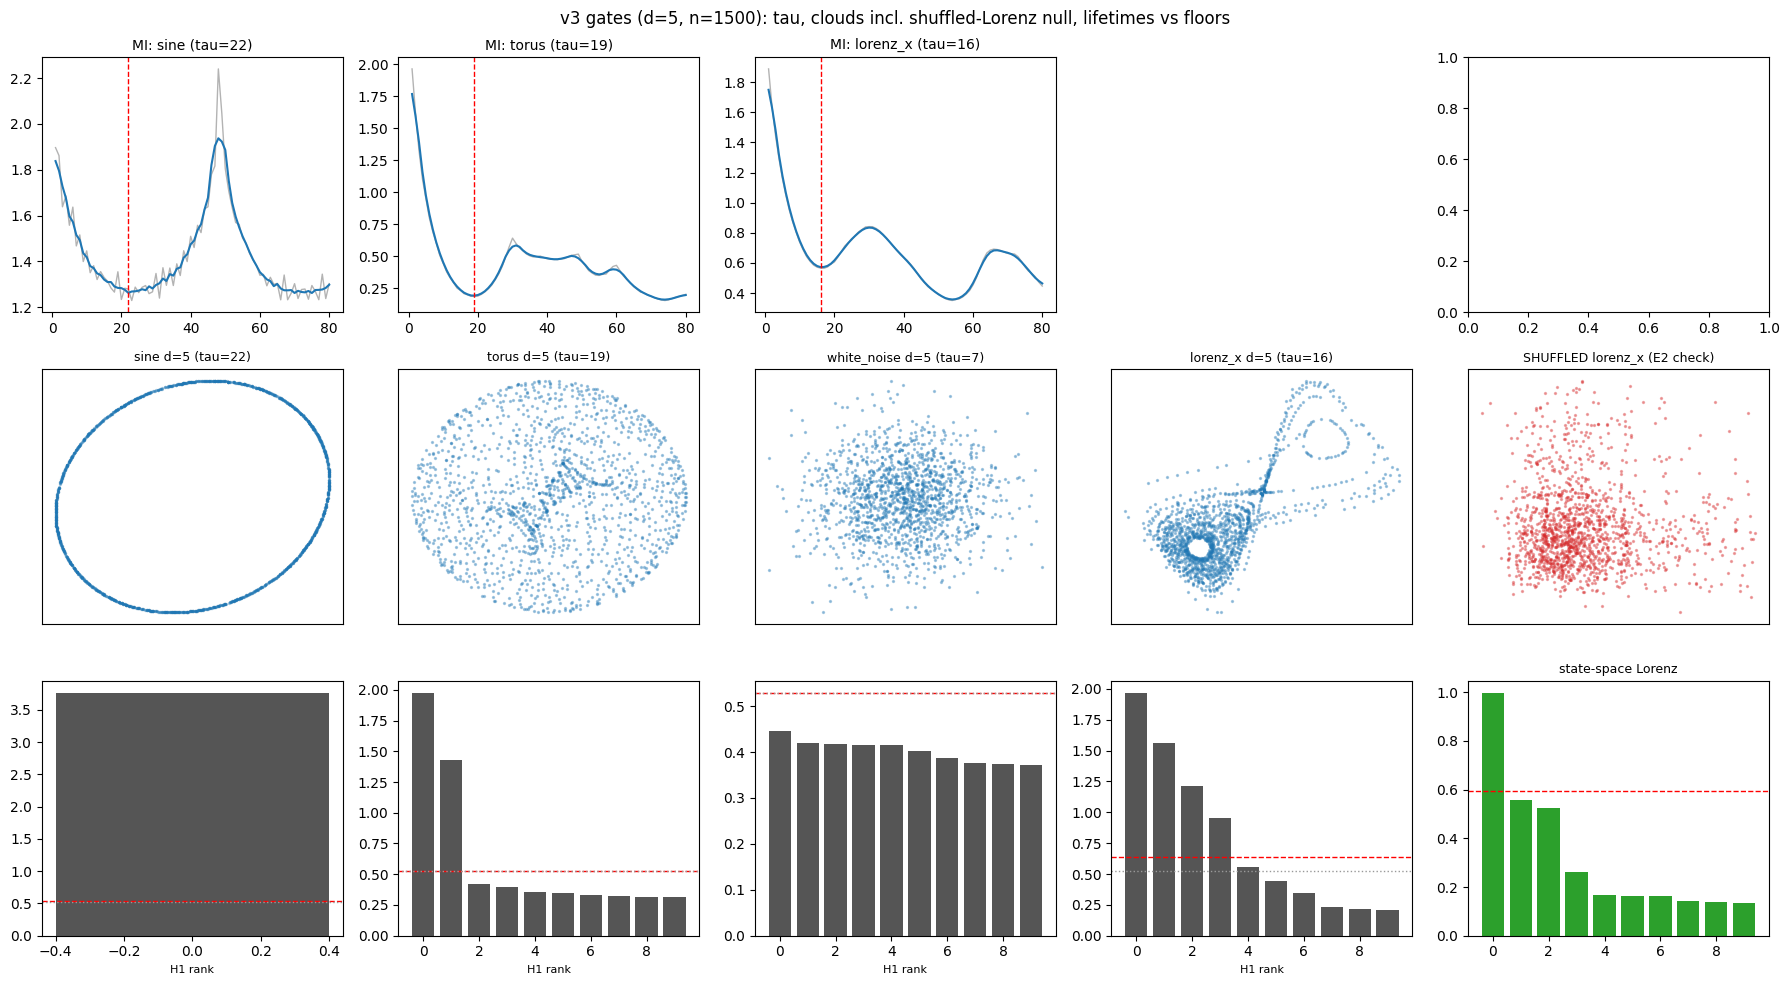

Saved tda_gate_visual_v3.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(18, 10))

for j, k in enumerate(['sine', 'torus', 'lorenz_x']):
    r = results[(k, D_PRIMARY)]
    ax = axes[0, j]
    ax.plot(range(1, len(r['mi_raw']) + 1), r['mi_raw'], color='0.7', lw=1)
    ax.plot(range(1, len(r['mi_smooth']) + 1), r['mi_smooth'], color='tab:blue', lw=1.5)
    ax.axvline(r['tau'], color='r', ls='--', lw=1)
    ax.set_title(f"MI: {k} (tau={r['tau']})", fontsize=10)
axes[0, 3].axis('off')

rng_viz = np.random.default_rng(3000)
shuf_lz = gate_analyse(rng_viz.permutation(lorenz_ctrl[:, 0]), d=D_PRIMARY, label='lorenz_x_shuffled')
show = ['sine', 'torus', 'white_noise', 'lorenz_x']
for j, k in enumerate(show):
    r = results[(k, D_PRIMARY)]
    ax = axes[1, j]
    ax.scatter(r['cloud'][:, 0], r['cloud'][:, 1], s=2, alpha=0.35)
    ax.set_title(f"{k} d=5 (tau={r['tau']})", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
ax = axes[1, 4]
ax.scatter(shuf_lz['cloud'][:, 0], shuf_lz['cloud'][:, 1], s=2, alpha=0.35, color='tab:red')
ax.set_title("SHUFFLED lorenz_x (E2 check)", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])

for j, k in enumerate(show):
    r = results[(k, D_PRIMARY)]
    ax = axes[2, j]
    lt = r['lifetimes'][:10]
    ax.bar(range(len(lt)), lt, color='#555')
    ax.axhline(floors_own[k], color='r', ls='--', lw=1)
    ax.axhline(wn_floor_d5, color='0.6', ls=':', lw=1)
    ax.set_xlabel('H1 rank', fontsize=8)
ax = axes[2, 4]
lt = ss['lifetimes'][:10]
ax.bar(range(len(lt)), lt, color='tab:green')
ax.axhline(ss_floor, color='r', ls='--', lw=1)
ax.set_title('state-space Lorenz', fontsize=9)

plt.suptitle('v3 gates (d=5, n=1500): tau, clouds incl. shuffled-Lorenz null, lifetimes vs floors')
plt.tight_layout()
plt.savefig('tda_gate_visual_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved tda_gate_visual_v3.png")

## Interpretation map (fixed before running)

| C (d=5) | G (state-space) | Conclusion |
|---|---|---|
| pass | pass | Instrument valid; mirror config, run real data |
| fail | pass | E1: delay reconstruction is the lossy step at N=3000 — try longer series / witness complexes before real data; do NOT run Weather as-is |
| fail | fail | E3: statistic weak even on ground truth — kill criterion met for max-H1 persistence; geometry branch needs a new instrument |
| pass | fail | Unexpected (would suggest the state-space null is inflated, E2, while delay-space is fine) — inspect floors table + shuffled-cloud panel |

If B_torus_top1 fails at d=5 while A and C pass: the instrument detects
single-frequency and chaotic loops but not multi-frequency ones —
Weather results would remain uninterpretable for periodicity-dominated
channels. Document and escalate before any real-data run.